# DBSCAN Sanity Check: Does Cluster Count Ever Decrease as a Video Grows?

**Question**: if we take the same video and look at longer and longer truncations of it, does the DBSCAN cluster count (our "dynamicity" proxy) ever *decrease*?

**Method (updated)**: no re-embedding or re-clustering here. `dbscan_frame_cluster_assignments.csv` already has one row per video and one column per frame (`frame 0` ... `frame 75`), holding the cluster label that frame was assigned in the full-video DBSCAN run. For each of two example videos (one with `n_clusters == 4`, one with `n_clusters == 8` in `dbscan_results.csv`), we grow a trailing window frame-by-frame — last 1 frame, last 2 frames, ... up to all 76 — and count how many *distinct* cluster labels appear among the frames currently in the window.

**⚠️ Important caveat — read before trusting this plot**: because the cluster *labels* come from a single, already-computed full-video clustering, and a growing trailing window only ever *adds* frames (never removes one that was already in), the set of distinct labels represented in the window can mathematically only grow or stay the same as the window grows — it can never shrink. In other words, **this version of the check is monotonic by construction, regardless of whether DBSCAN's own clustering behavior is well-behaved under truncation.** It verifies something real (that the full-video clustering is internally consistent / that we're slicing it correctly) but it does *not* test whether DBSCAN, if actually *re-run* on a truncated sub-clip in isolation, would still find a non-decreasing cluster count — that would require rerunning DBSCAN independently per truncation length (the embedding-based version of this notebook, kept below in git history / the previous version, does that). If the point of the sanity check is specifically to catch DBSCAN behaving inconsistently when it sees less context, this simplified version can't catch that by design — flagging this so you can decide which question you actually need answered.

**Assumptions made here — double check against the real files**:
- `dbscan_frame_cluster_assignments.csv`: a `video` column (bare video ID, no `.mp4`) plus one column per frame, chronological order (`frame 0` = start of the clip, `frame 75` = end).
- Noise convention: label `-1` = DBSCAN noise (standard sklearn convention, consistent with `dbscan_results.csv` tracking `n_noise_points` separately from `n_clusters`); missing/`NaN` = video shorter than 76 frames, no real frame at that position.
- Frames were sampled at 5Hz (one every 200ms), so frame index ÷ 5 = seconds — used only to label the x-axis in seconds; adjust if the real sampling rate differs.
- This still needs `/braintree/...` access, but no GPU / no video decoding anymore — much cheaper, can run on a login node.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [2]:
DBSCAN_RESULTS_CSV = "/braintree/data2/active/users/aicha/results/entire_dataset/dbscan_analysis_outputs/dbscan_results.csv"
FRAME_ASSIGNMENTS_CSV = "/braintree/data2/active/users/aicha/results/entire_dataset/dbscan_analysis_outputs/dbscan_frame_cluster_assignments.csv"

SAMPLING_HZ = 5  # one frame every 200ms -- only used to label the x-axis in seconds
NOISE_LABEL = -1

TARGET_N_CLUSTERS = [4, 8]  # pick one video with each of these cluster counts

## Load both CSVs and pick two example videos

Inspecting `.columns`/`.head()` first for both files — if the real column names/format differ from what's assumed above, this will make it obvious immediately.

In [3]:
dbscan_df = pd.read_csv(DBSCAN_RESULTS_CSV)
print(dbscan_df.columns.tolist())
dbscan_df.head()

['video', 'video_index', 'n_clusters', 'n_noise_points', 'n_frames', 'embedding_dim', 'dbscan_time_sec']


,video,video_index,n_clusters,n_noise_points,n_frames,embedding_dim,dbscan_time_sec
0,0_458b9f39-85ee-4d6f-82ec-9d219cbe31cd,0,2,5,17,1536,0.213322
1,10000_4840195a-580a-44c9-b1de-4bbb792473b5,1,1,0,17,1536,0.109394
2,10001_9db30b24-9088-408f-b34d-330d0fa57749,2,1,0,26,1536,0.113327
3,10002_96f40437-44a8-4350-84ee-c5cef142741c,3,1,0,26,1536,0.110369
4,10003_ae96e89e-075d-44a7-b5d4-a85073a71c36,4,1,0,5,1536,0.106434


In [4]:
frames_df = pd.read_csv(FRAME_ASSIGNMENTS_CSV)
print(frames_df.columns.tolist())
frames_df.head()

['video', 'frame1', 'frame2', 'frame3', 'frame4', 'frame5', 'frame6', 'frame7', 'frame8', 'frame9', 'frame10', 'frame11', 'frame12', 'frame13', 'frame14', 'frame15', 'frame16', 'frame17', 'frame18', 'frame19', 'frame20', 'frame21', 'frame22', 'frame23', 'frame24', 'frame25', 'frame26', 'frame27', 'frame28', 'frame29', 'frame30', 'frame31', 'frame32', 'frame33', 'frame34', 'frame35', 'frame36', 'frame37', 'frame38', 'frame39', 'frame40', 'frame41', 'frame42', 'frame43', 'frame44', 'frame45', 'frame46', 'frame47', 'frame48', 'frame49', 'frame50', 'frame51', 'frame52', 'frame53', 'frame54', 'frame55', 'frame56', 'frame57', 'frame58', 'frame59', 'frame60', 'frame61', 'frame62', 'frame63', 'frame64', 'frame65', 'frame66', 'frame67', 'frame68', 'frame69', 'frame70', 'frame71', 'frame72', 'frame73', 'frame74', 'frame75']


,video,frame1,frame2,frame3,frame4,frame5,frame6,frame7,frame8,frame9,...,frame66,frame67,frame68,frame69,frame70,frame71,frame72,frame73,frame74,frame75
0,0_458b9f39-85ee-4d6f-82ec-9d219cbe31cd,-1,0.0,0.0,0.0,-1.0,-1.0,-1.0,1.0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000_4840195a-580a-44c9-b1de-4bbb792473b5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001_9db30b24-9088-408f-b34d-330d0fa57749,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10002_96f40437-44a8-4350-84ee-c5cef142741c,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10003_ae96e89e-075d-44a7-b5d4-a85073a71c36,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# detect the frame columns robustly (handles "frame 0", "frame_0", "Frame0", ...)
# and sort them into chronological order (frame 0 first, last frame last).
frame_col_pattern = re.compile(r"frame[\s_]*?(\d+)", re.IGNORECASE)
frame_cols = [c for c in frames_df.columns if frame_col_pattern.search(c)]
frame_cols = sorted(frame_cols, key=lambda c: int(frame_col_pattern.search(c).group(1)))

print(f"Found {len(frame_cols)} frame columns: {frame_cols[0]} ... {frame_cols[-1]}")

Found 75 frame columns: frame1 ... frame75


In [6]:
example_videos = {}
for target in TARGET_N_CLUSTERS:
    matches = dbscan_df.loc[dbscan_df["n_clusters"] == target]
    assert len(matches) > 0, f"No video found with n_clusters == {target}"
    video_id = matches.iloc[0]["video"]

    assert (frames_df["video"] == video_id).any(), (
        f"video={video_id} (n_clusters={target} in {DBSCAN_RESULTS_CSV}) "
        f"not found in {FRAME_ASSIGNMENTS_CSV} -- check the 'video' ID format matches between the two files."
    )

    example_videos[target] = video_id
    print(f"n_clusters={target}  ->  video={video_id}")

example_videos

n_clusters=4  ->  video=10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df
n_clusters=8  ->  video=10168_f372cf01-3af2-4a3d-bce9-11b92d75f402


{4: '10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df',
 8: '10168_f372cf01-3af2-4a3d-bce9-11b92d75f402'}

## Run the sanity check: grow each video from the end, frame by frame

In [7]:
def cluster_and_noise_counts(labels):
    """labels: 1D array of per-frame cluster labels (may contain NaN for missing frames)."""
    real = labels[~pd.isna(labels)]
    n_clusters = len(set(real) - {NOISE_LABEL})
    n_noise = int((real == NOISE_LABEL).sum())
    return n_clusters, n_noise


results = []

for target_n_clusters, video_id in example_videos.items():
    row = frames_df.loc[frames_df["video"] == video_id, frame_cols].iloc[0]
    labels_chronological = row.to_numpy(dtype=float)  # frame 0 (start) ... frame N-1 (end)

    # how many of the frame columns are actually real (non-NaN) for this video
    n_real_frames = int((~pd.isna(labels_chronological)).sum())

    for n_frames_kept in range(1, n_real_frames + 1):
        # keep the LAST n_frames_kept real frames -- truncation removes from
        # the beginning, real content stays anchored at the end (matches the
        # model's own padding/segment convention)
        window = labels_chronological[n_real_frames - n_frames_kept : n_real_frames]

        n_clusters, n_noise = cluster_and_noise_counts(window)
        results.append({
            "video": video_id,
            "original_n_clusters": target_n_clusters,
            "n_frames_kept": n_frames_kept,
            "truncation_sec": n_frames_kept / SAMPLING_HZ,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
        })

results_df = pd.DataFrame(results).sort_values(["video", "n_frames_kept"]).reset_index(drop=True)
results_df.to_csv("dbscan_sanity_check_results.csv", index=False)
results_df

,video,original_n_clusters,n_frames_kept,truncation_sec,n_clusters,n_noise
0,10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df,4,1,0.2,1,0
1,10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df,4,2,0.4,1,0
2,10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df,4,3,0.6,1,0
3,10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df,4,4,0.8,2,0
4,10011_64747fa7-c7b9-46fc-ac9d-ea9a514d91df,4,5,1.0,2,0
...,...,...,...,...,...,...
93,10168_f372cf01-3af2-4a3d-bce9-11b92d75f402,8,54,10.8,7,21
94,10168_f372cf01-3af2-4a3d-bce9-11b92d75f402,8,55,11.0,7,22
95,10168_f372cf01-3af2-4a3d-bce9-11b92d75f402,8,56,11.2,7,23
96,10168_f372cf01-3af2-4a3d-bce9-11b92d75f402,8,57,11.4,8,23


## Plot: cluster count vs. truncation duration, one panel per video

Grouped into 1s increments (every 5 frames, since sampling is 5Hz) rather than one bar per frame; noise points aren't plotted (the sanity check is about cluster count only); the two videos are stacked vertically rather than side by side.

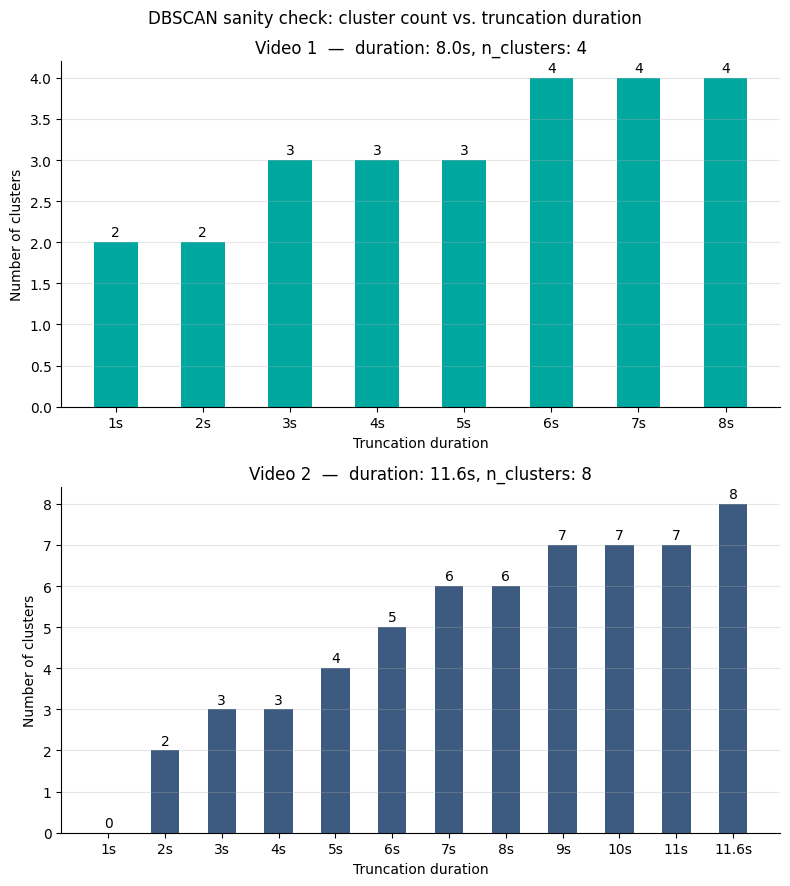

In [8]:
FRAME_GROUP_SIZE = 5  # 5 frames = 1s at 5Hz
PANEL_COLORS = ["#00A79F", "#3D5A80"]  # teal, slate blue


def fmt_sec(t):
    return f"{t:.0f}s" if abs(t - round(t)) < 1e-6 else f"{t:.1f}s"


fig, axes = plt.subplots(len(example_videos), 1, figsize=(8, 4.5 * len(example_videos)))
if len(example_videos) == 1:
    axes = [axes]

for i, ((target_n_clusters, video_id), ax, color) in enumerate(
    zip(example_videos.items(), axes, PANEL_COLORS), start=1
):
    sub = results_df.loc[results_df["video"] == video_id].sort_values("n_frames_kept")
    max_frames = sub["n_frames_kept"].max()
    duration_sec = max_frames / SAMPLING_HZ

    # group frames by 5 (one point per second) -- always keep the final point
    # too, so the full video is represented even if its length isn't an exact
    # multiple of 5 frames
    keep_mask = (sub["n_frames_kept"] % FRAME_GROUP_SIZE == 0) | (sub["n_frames_kept"] == max_frames)
    grouped = sub.loc[keep_mask]

    x = np.arange(len(grouped))
    bars = ax.bar(x, grouped["n_clusters"], width=0.5, color=color)
    ax.bar_label(bars, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels([fmt_sec(t) for t in grouped["truncation_sec"]])
    ax.set_xlabel("Truncation duration")
    ax.set_ylabel("Number of clusters")
    ax.set_title(f"Video {i}  —  duration: {duration_sec:.1f}s, n_clusters: {target_n_clusters}")
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("DBSCAN sanity check: cluster count vs. truncation duration")
fig.tight_layout()
fig.savefig("dbscan_sanity_check_plot.png", dpi=150)
plt.show()

## Check monotonicity explicitly

Given the caveat above, expect this to report "MONOTONIC" for every video by construction — it's a check that the slicing/counting logic is correct, not (on its own) a check of DBSCAN's re-clustering behavior.

In [ ]:
for video_id, sub in results_df.groupby("video"):
    sub = sub.sort_values("n_frames_kept")
    diffs = np.diff(sub["n_clusters"].values)
    n_decreases = int((diffs < 0).sum())
    status = "MONOTONIC (non-decreasing)" if n_decreases == 0 else f"NOT monotonic -- {n_decreases} decrease(s)"
    print(f"video={video_id}: {status}")
    if n_decreases > 0:
        drop_points = sub.iloc[1:][diffs < 0]
        print(drop_points[["truncation_sec", "n_clusters"]])